# Digital Professor: Recognition Demo

This notebook tests the same recognition contracts that a later browser UI and FastAPI backend can call. API-backed cells remain optional until `OPENAI_API_KEY` is set in the root `.env`.

In [1]:
# python3 -m venv .venv
# source .venv/bin/activate
# pip install -r requirements.txt

In [2]:
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'research' / 'interaction-methods').is_dir()
)
PACKAGE_ROOT = ROOT / 'research' / 'interaction-methods' / 'src'
sys.path.insert(0, str(PACKAGE_ROOT))

from digital_professor import (
    RecognitionService,
    ingest_document,
    load_settings,
    render_document,
)
from digital_professor.equations import extract_delimited_equations

TEST_DATA = ROOT / 'resources' / 'interaction_test'
settings = load_settings(ROOT / '.env')
print(f'Project root: {ROOT}')
print(f'Model: {settings.openai_model}; API enabled: {settings.api_enabled}')

Project root: /Users/jonathanma/Desktop/Projects/digital-professor
Model: gpt-4o; API enabled: True


## Part 1 — Text/equation ingestion and generation

First inspect deterministic embedded-text extraction. This step makes no API call and keeps page provenance.

In [3]:
notes_path = TEST_DATA / 'samp_notes.pdf'
notes = ingest_document(notes_path, max_pages=3)
print(f'{len(notes.pages)} page(s), {len(notes.combined_text):,} extracted characters')
display(Markdown(f'```text\n{notes.combined_text[:3000]}\n```'))

3 page(s), 5,345 extracted characters


```text
Notes 1: Foundations of Nonlinear Optimization
Instructor: [name removed]
Fall 2026
Suggested Reading: Wright and Recht, Chapter 2; Boyd and Vandenberghe, Chapters 2–3.
This lecture introduces the language used throughout the course. We begin with general smooth
nonlinear optimization and then introduce concepts related to convexity.
1
Optimization problems and solutions
The unconstrained problem has the form
min
x∈Rn f(x),
(1)
where the objective f : dom f →R may be smooth or nonsmooth and may be convex or nonconvex.
A constrained problem is written as
min
x∈Ωf(x),
(2)
where Ω⊆dom f is the feasible set.
Definition 1.1 (Local and global solutions). A feasible point x∗is a local solution of (2) if there
is r > 0 such that
f(x∗) ≤f(x)
for all x ∈Ω∩{x : ∥x −x∗∥< r}.
It is a strict local solution if the inequality is strict whenever x̸ = x∗, and a global solution if it
holds for every x ∈Ω. The solution is unique if no other global solution exists.
We denote the optimal value by f∗= infx∈Ωf(x). The infimum need not be attained. For
example, infx∈R ex = 0, but there is no minimizer. Existence generally follows when a continuous
objective is minimized over a nonempty compact feasible set. More generally, a lower semicontin-
uous, coercive function on a closed set attains its infimum.
Definition 1.2 (Coercivity). A function f : Rn →R is coercive if f(x) →+∞whenever ∥x∥→∞.
2
Derivatives and Taylor’s expansion
For a differentiable f,
f(x + p) = f(x) + ∇f(x)T p + o(∥p∥).
(3)
If f is twice differentiable, then
f(x + p) = f(x) + ∇f(x)T p + 1
2pT ∇2f(x)p + o(∥p∥2).
(4)
Here ∇f(x) is the gradient of f, and ∇2f(x) is its Hessian.
1

Nonlinear Optimization
Notes 1: Foundations of Nonlinear Optimization
Theorem 2.1 (Taylor’s theorem in integral form). If f is continuously differentiable on the line
segment from x to x + p, then
f(x + p) = f(x) +
Z 1
0
∇f(x + tp)T p dt.
If f is twice continuously differentiable on the line segment, then
f(x + p) = f(x) + ∇f(x)T p +
Z 1
0
(1 −t)pT ∇2f(x + tp)p dt.
Proof. Define the scalar function ϕ(t) = f(x + tp) for t ∈[0, 1].
The chain rule gives ϕ′(t) =
∇f(x + tp)T p, so the fundamental theorem of calculus gives
f(x + p) −f(x) = ϕ(1) −ϕ(0) =
Z 1
0
ϕ′(t) dt.
If f is twice continuously differentiable, then ϕ′′(t) = pT ∇2f(x + tp)p. Applying the fundamental
theorem of calculus again gives
ϕ(1) −ϕ(0) −ϕ′(0) =
Z 1
0
 ϕ′(t) −ϕ′(0)
 dt
=
Z 1
0
Z t
0
ϕ′′(s) ds dt =
Z 1
0
(1 −s)ϕ′′(s) ds.
2.1
Lipschitz continuity and smoothness
Definition 2.2 (Lipschitz function and Lipschitz gradient). A function f is G-Lipschitz on D if
|f(x) −f(y)| ≤G∥x −y∥,
x, y ∈D.
A differentiable function f is L-smooth on D if
∥∇f(x) −∇f(y)∥≤L∥x −y∥,
x, y ∈D.
Lemma 2.3 (Descent lemma). Let D be convex. If f is L-smooth on D, then for all x, y ∈D,
f(y) ≤f(x) + ∇f(x)T (y −x) + L
2 ∥y −x∥2.
(5)
Proof. Set p = y −x and apply Taylor’s theorem:
f(y) −f(x) −∇f(x)T p =
Z 1
0
 ∇f(x + tp) −∇f(x)
T p dt
≤
Z 1
0
Lt∥p∥2 dt = L
2 ∥p∥2.
Lemma 2.4 (Smoothness and the Hessian).
```

The local equation helper only claims expressions that already have TeX delimiters. PDF glyph recovery is left to visual/model recognition because ordinary text extraction often loses equation layout.

In [4]:
typed_example = r'''For $f(x)=x^2$, the derivative is $f'(x)=2x$.
The normal equation is $$\hat{\beta}=(X^T X)^{-1}X^T y.$$'''
equations = extract_delimited_equations(typed_example)
display(Markdown(typed_example))
[item.model_dump() for item in equations]

For $f(x)=x^2$, the derivative is $f'(x)=2x$.
The normal equation is $$\hat{\beta}=(X^T X)^{-1}X^T y.$$

[{'latex': 'f(x)=x^2',
  'source_text': 'f(x)=x^2',
  'confidence': 1.0,
  'ambiguous': False,
  'alternatives': []},
 {'latex': "f'(x)=2x",
  'source_text': "f'(x)=2x",
  'confidence': 1.0,
  'ambiguous': False,
  'alternatives': []},
 {'latex': '\\hat{\\beta}=(X^T X)^{-1}X^T y.',
  'source_text': '\\hat{\\beta}=(X^T X)^{-1}X^T y.',
  'confidence': 1.0,
  'ambiguous': False,
  'alternatives': []}]

### Model-assisted normalization and answer generation

This converts extracted PDF text to structured Markdown/LaTeX, then asks one grounded question. It runs only when a key is available.

In [5]:
if settings.api_enabled:
    service = RecognitionService(settings)
    typed_result = service.recognize_embedded_text(notes_path)
    for page in typed_result.pages:
        display(Markdown(f'### Page {page.page_number}\n{page.markdown}'))
        if page.uncertainties:
            print('Review:', page.uncertainties)
    display({'request_metadata': [item.model_dump() for item in typed_result.requests]})
else:
    typed_result = None
    print('Skipped: add OPENAI_API_KEY to .env, restart the kernel, and rerun.')

### Page 1
# Notes 1: Foundations of Nonlinear Optimization

Instructor: [name removed]  
Fall 2026

Suggested Reading: Wright and Recht, Chapter 2; Boyd and Vandenberghe, Chapters 2–3.

This lecture introduces the language used throughout the course. We begin with general smooth nonlinear optimization and then introduce concepts related to convexity.

## Optimization problems and solutions

The unconstrained problem has the form

$$ \min_{x \in \mathbb{R}^n} f(x), $$

where the objective $f: \text{dom } f \rightarrow \mathbb{R}$ may be smooth or nonsmooth and may be convex or nonconvex.

A constrained problem is written as

$$ \min_{x \in \Omega} f(x), $$

where $\Omega \subseteq \text{dom } f$ is the feasible set.

### Definition 1.1 (Local and global solutions).

A feasible point $x^*$ is a local solution of (2) if there is $r > 0$ such that

$$ f(x^*) \leq f(x) $$

for all $x \in \Omega \cap \{x : \|x - x^*\| < r\}$.

It is a strict local solution if the inequality is strict whenever $x \neq x^*$, and a global solution if it holds for every $x \in \Omega$. The solution is unique if no other global solution exists.

We denote the optimal value by $f^* = \inf_{x \in \Omega} f(x)$. The infimum need not be attained. For example, $\inf_{x \in \mathbb{R}} e^x = 0$, but there is no minimizer. Existence generally follows when a continuous objective is minimized over a nonempty compact feasible set. More generally, a lower semicontinuous, coercive function on a closed set attains its infimum.

### Definition 1.2 (Coercivity).

A function $f : \mathbb{R}^n \rightarrow \mathbb{R}$ is coercive if $f(x) \rightarrow +\infty$ whenever $\|x\| \rightarrow \infty$.

## Derivatives and Taylor’s expansion

For a differentiable $f$,

$$ f(x + p) = f(x) + \nabla f(x)^T p + o(\|p\|). $$

If $f$ is twice differentiable, then

$$ f(x + p) = f(x) + \nabla f(x)^T p + \frac{1}{2} p^T \nabla^2 f(x) p + o(\|p\|^2). $$

Here $\nabla f(x)$ is the gradient of $f$, and $\nabla^2 f(x)$ is its Hessian.

---

# Nonlinear Optimization  
Notes 1: Foundations of Nonlinear Optimization

## Theorem 2.1 (Taylor’s theorem in integral form).

If $f$ is continuously differentiable on the line segment from $x$ to $x + p$, then

$$ f(x + p) = f(x) + \int_0^1 \nabla f(x + tp)^T p \; dt. $$

If $f$ is twice continuously differentiable on the line segment, then

$$ f(x + p) = f(x) + \nabla f(x)^T p + \int_0^1 (1 - t) p^T \nabla^2 f(x + tp) p \; dt. $$

Proof. Define the scalar function $\phi(t) = f(x + tp)$ for $t \in [0, 1]$.

The chain rule gives $\phi'(t) = \nabla f(x + tp)^T p$, so the fundamental theorem of calculus gives

$$ f(x + p) - f(x) = \phi(1) - \phi(0) = \int_0^1 \phi'(t) \; dt. $$

If $f$ is twice continuously differentiable, then $\phi''(t) = p^T \nabla^2 f(x + tp) p$. Applying the fundamental theorem of calculus again gives

$$ \phi(1) - \phi(0) - \phi'(0) = \int_0^1 \left[ \phi'(t) - \phi'(0) \right] \; dt = \int_0^1 \int_0^t \phi''(s) \; ds \; dt = \int_0^1 (1 - s) \phi''(s) \; ds. $$

### Page 2
## Lipschitz continuity and smoothness

### Definition 2.2 (Lipschitz function and Lipschitz gradient).

A function $f$ is $G$-Lipschitz on $D$ if

$$ |f(x) - f(y)| \leq G\|x - y\|, \quad x, y \in D. $$

A differentiable function $f$ is $L$-smooth on $D$ if

$$ \|\nabla f(x) - \nabla f(y)\| \leq L\|x - y\|, \quad x, y \in D. $$

### Lemma 2.3 (Descent lemma).

Let $D$ be convex. If $f$ is $L$-smooth on $D$, then for all $x, y \in D$,

$$ f(y) \leq f(x) + \nabla f(x)^T (y - x) + \frac{L}{2} \|y - x\|^2. $$

Proof.

Set $p = y - x$ and apply Taylor’s theorem:

$$ f(y) - f(x) - \nabla f(x)^T p = \int_0^1 \left[ \nabla f(x + tp) - \nabla f(x) \right]^T p \; dt \leq \int_0^1 Lt\|p\|^2 \; dt = \frac{L}{2} \|p\|^2. $$

### Lemma 2.4 (Smoothness and the Hessian).

Suppose $f$ is twice continuously differentiable on an open convex set $D$. If

$$ -LI \preceq \nabla^2 f(x) \preceq LI $$

for every $x \in D$,

then $f$ is $L$-smooth on $D$. Conversely, if $f$ is $L$-smooth, then $\|\nabla^2 f(x)\|_2 \leq L$ for every $x \in D$. If $f$ is also convex, this becomes $0 \preceq \nabla^2 f(x) \preceq LI$.

---

## Optimality conditions for smooth problems

### Theorem 3.1 (Unconstrained first- and second-order conditions).

Let $x^*$ be a local minimizer of (1) lying in the interior of $\text{dom } f$.

1. If $f$ is differentiable at $x^*$, then $\nabla f(x^*) = 0$.
2. If $f$ is twice differentiable at $x^*$, then $\nabla^2 f(x^*) \succeq 0$.
3. Conversely, if $\nabla f(x^*) = 0$ and $\nabla^2 f(x^*) \succ 0$, with the Hessian continuous near $x^*$, then $x^*$ is a strict local minimizer.

Proof.

If $\nabla f(x^*) \neq 0$, let $p = -\nabla f(x^*)$. By differentiability,

$$ f(x^* + tp) = f(x^*) + t\nabla f(x^*)^T p + o(t) = f(x^*) - t\|\nabla f(x^*)\|^2 + o(t) < f(x^*) $$

for all sufficiently small $t > 0$, a contradiction.

For the second statement, suppose some $v$ satisfies $v^T \nabla^2 f(x^*) v < 0$. Since $\nabla f(x^*) = 0$, Taylor’s theorem gives

$$ f(x^* + tv) = f(x^*) + \frac{t^2}{2} v^T \nabla^2 f(x^* + \theta tv)v < f(x^*) $$

for all sufficiently small $t > 0$ and some $\theta \in (0, 1)$, again a contradiction.

Finally, if $\nabla^2 f(x^*) \succ 0$, continuity gives $r > 0$ and $m > 0$ such that $\nabla^2 f(z) \succeq mI$ whenever $\|z - x^*\| \leq r$. Taylor’s theorem then yields

$$ f(x^* + p) \geq f(x^*) + \frac{m}{2} \|p\|^2 > f(x^*) $$

for every nonzero $p$ with $\|p\| \leq r$.

The equation $\nabla f(x) = 0$ defines a stationary point. For nonconvex problems, stationarity is necessary but not sufficient for local optimality: $f(x) = x^3$ is stationary at zero but has no local minimum there. Likewise, the positive-semidefinite Hessian condition is not sufficient: $f(x) = x^3$ and $f(x) = -x^4$ both have zero Hessian at zero.

For a closed feasible set $\Omega$, define its convex-analysis normal cone at $x \in \Omega$ by

$$ N_\Omega(x) = \{v \in \mathbb{R}^n : v^T (y - x) \leq 0 \text{ for all } y \in \Omega\}. $$

When $f$ and $\Omega$ are convex, the constrained first-order condition is

$$ 0 \in \nabla f(x^*) + N_\Omega(x^*), $$

or equivalently $\nabla f(x^*)^T (y - x^*) \geq 0$ for every $y \in \Omega$. 

### Page 3
### Proposition 3.2 (Constrained first-order condition).

Let $f$ be differentiable and convex and let $\Omega$ be nonempty and convex. Then $x^* \in \Omega$ minimizes $f$ over $\Omega$ if and only if

$$ 0 \in \nabla f(x^*) + N_\Omega(x^*). $$

Proof.

If $x^*$ is optimal, fix $y \in \Omega$ and consider $\phi(t) = f(x^* + t(y - x^*))$ on $[0, 1]$. Since $t = 0$ minimizes $\phi$, its right derivative is nonnegative, so

$$ \nabla f(x^*)^T (y - x^*) \geq 0. $$

Thus $-\nabla f(x^*) \in N_\Omega(x^*)$.

Conversely, this inequality and convexity give

$$ f(y) \geq f(x^*) + \nabla f(x^*)^T (y - x^*) \geq f(x^*) $$

for every $y \in \Omega$.

---

## Convex sets

### Definition 4.1 (Affine and convex sets).

A set $C \subseteq \mathbb{R}^n$ is affine if it contains the entire line through any two of its points. It is convex if

$$ x, y \in C, \quad \theta \in [0, 1] \implies \theta x + (1 - \theta)y \in C. $$

A convex cone contains every conic combination $\theta_1 x + \theta_2 y$ with $\theta_1, \theta_2 \geq 0$.

The convex hull of $S$ is the smallest convex set containing $S$:

$$ \text{conv}(S) = \left( \sum_{i=1}^{m} \theta_i x_i : x_i \in S, \theta_i \geq 0, \sum_{i=1}^{m} \theta_i = 1, m \geq 1 \right). $$

Important examples include

- affine spaces $\{x : Ax = b\}$, hyperplanes, and halfspaces;
- norm balls $\{x : \|x - x_c\| \leq r\}$ and norm cones $\{(x, t) : \|x\| \leq t\}$;
- polyhedra $\{x : Ax \leq b, Cx = d\}$; and
- the positive-semidefinite cone $S^n_+ = \{X = X^T : z^T Xz \geq 0 \text{ for all } z\}$.

### Proposition 4.2 (Operations preserving convexity).

The following sets are convex:

1. any intersection of convex sets;
2. the image $AC + b = \{Ax + b : x \in C\}$ of a convex set under an affine map;
3. the inverse image $\{x : Ax + b \in D\}$ of a convex set under an affine map;
4. a coordinate projection of a convex set.

Proof.

For an intersection, a convex combination of two points belongs to every set in the family and hence to their intersection. If $u_i = Ax_i + b \in AC + b$, then

$$ \theta u_1 + (1 - \theta) u_2 = A (\theta x_1 + (1 - \theta) x_2) + b \in AC + b. $$

The inverse-image argument is analogous. A coordinate projection is a linear image, so it follows from the second case.

---

### Example 4.3 (Linear matrix inequality).

For symmetric matrices $A_0, A_1, \ldots, A_n$, the set

$$ \left( x \in \mathbb{R}^n : A_0 + \sum_{i=1}^{n} x_i A_i \succeq 0 \right) $$

is convex because it is the affine inverse image of $S^m_+$.

---

## Theorem 4.4 (Separation, informal form).

If a point $z$ does not belong to a nonempty closed convex set $C$, there are $a \neq 0$ and $b$ such that

$$ a^T x \leq b < a^T z $$

for all $x \in C$.

Every boundary point of a convex set with nonempty interior has a supporting hyperplane.

Proof.

Let $\bar{x} = \text{proj}_C(z)$ be the Euclidean projection of $z$ onto $C$ and put $a = z - \bar{x}$. The function $t \mapsto \|z - (\bar{x} + t(y - \bar{x}))\|^2$ is minimized over $[0, 1]$ at $t = 0$ for every $y \in C$. Its right derivative is nonnegative, giving $a^T (y - \bar{x}) \leq 0$. With $b = a^T \bar{x}$,

$$ a^T y \leq b < a^T z, $$

where the strict inequality follows from $a^T z - b = \|z - \bar{x}\|^2 > 0.$

### Page 4
## Convex functions

### Definition 5.1 (Convexity).

A function $f : \mathbb{R}^n \rightarrow \mathbb{R} \cup \{+\infty\}$ is convex if $\text{dom } f$ is convex and

$$ f(\theta x + (1 - \theta)y) \leq \theta f(x) + (1 - \theta) f(y) $$

for all $x, y \in \text{dom } f$ and $\theta \in [0, 1]$. It is strictly convex when the inequality is strict for $x \neq y$ and $\theta \in (0, 1)$. It is concave when $-f$ is convex.

Allowing $+\infty$ incorporates constraints into the objective. If $\delta_C(x) = 0$ on $C$ and $+\infty$ outside $C$, then minimizing $f + \delta_C$ is equivalent to minimizing $f$ over $C$.

### Theorem 5.2 (Equivalent convexity tests).

Let $\text{dom } f$ be convex.

1. $f$ is convex if and only if its restriction $t \mapsto f(x + td)$ is convex on every line intersecting $\text{dom } f$.
2. If $f$ is differentiable, it is convex if and only if

   $$ f(y) \geq f(x) + \nabla f(x)^T (y - x), \quad x, y \in \text{dom } f. $$

3. If $f$ is twice differentiable on an open domain, it is convex if and only if $\nabla^2 f(x) \succeq 0$ for every $x \in \text{dom } f$.

Proof.

The line-restriction statement follows by writing every point on a segment as $x + td$; the reverse implication applies the one-dimensional convexity inequality to the line through arbitrary $x$ and $y$.

Suppose $f$ is differentiable and convex. Apply convexity to $x + t(y - x)$, subtract $f(x)$, divide by $t > 0$, and let $t \downarrow 0$ to obtain (9). Conversely, let $z = (1 - \theta)x + \theta y$. Applying (9) at $z$ to $x$ and $y$, multiplying by $1 - \theta$ and $\theta$, and adding cancels the linear terms and gives

$$ f(z) \leq (1 - \theta)f(x) + \theta f(y). $$

Finally, restrict $f$ to a line. Its second derivative is $d^T \nabla^2 f(x + td)d$. A twice differentiable scalar function is convex exactly when its second derivative is nonnegative.

{'request_metadata': [{'response_id': 'resp_03d0fce9af95a0fc016aa3f3c3fe4487d2b18bfd6868bfae23',
   'model': 'gpt-4o-2024-08-06',
   'elapsed_seconds': 52.305563957896084,
   'input_tokens': 3969,
   'output_tokens': 7464,
   'total_tokens': 11433,
   'estimated_cost_usd': None,
   'cost_basis': None}]}

In [6]:
if typed_result is not None:
    context = '\n\n'.join(page.markdown for page in typed_result.pages)
    generated = service.generate(
        'Choose one equation from these notes, explain every symbol, and give a short check-for-understanding question.',
        context,
    )
    display(Markdown(generated.answer_markdown))
    display({'request_metadata': generated.request.model_dump()})

Let's choose the unconstrained optimization problem:

$$ \min_{x \in \mathbb{R}^n} f(x). $$

### Explanation of Symbols:
- The expression $\min_{x \in \mathbb{R}^n} f(x)$ indicates that we are looking for the minimum value of the function $f$.
- $x \in \mathbb{R}^n$ means that the variable $x$ is a vector in an n-dimensional real space. It is the variable we can adjust to find the minimum of $f$.
- $f(x)$ is the objective function we intend to minimize, which maps from the domain of $f$ to the set of real numbers $\mathbb{R}$.

### Check-for-Understanding Question:
What does it mean for a point $x^*$ to be a local solution to the equation given above?

{'request_metadata': {'response_id': 'resp_0be4c0bb92d632fa016aa3f3f6ec7487d291be48654b7fdb9e',
  'model': 'gpt-4o-2024-08-06',
  'elapsed_seconds': 2.4392632921226323,
  'input_tokens': 4097,
  'output_tokens': 184,
  'total_tokens': 4281,
  'estimated_cost_usd': None,
  'cost_basis': None}}

### Ask the Digital Professor

Edit `student_request` to contain a question, an equation, or both. The tutoring layer interprets the request, provides a worked explanation, states assumptions, and checks understanding. Recognized notes are included as optional context when available.

In [7]:
student_request = r'Why does $\nabla f(x)=0$ not guarantee a minimum? Give an example.'

if settings.api_enabled:
    service = RecognitionService(settings)
    tutor_context = (
        '\n\n'.join(page.markdown for page in typed_result.pages)
        if typed_result is not None
        else None
    )
    tutoring = service.help_student(student_request, context=tutor_context)
    display(Markdown(f'**Interpreted request:** {tutoring.interpreted_question}'))
    if tutoring.detected_equations:
        display({'detected_equations': tutoring.detected_equations})
    display(Markdown(tutoring.answer_markdown))
    if tutoring.assumptions:
        display({'assumptions': tutoring.assumptions})
    display(Markdown(f'**Check your understanding:** {tutoring.comprehension_check}'))
    display({'request_metadata': tutoring.request.model_dump()})
else:
    print('Skipped: add OPENAI_API_KEY to .env, restart the kernel, and rerun.')

**Interpreted request:** Why does the condition $\nabla f(x) = 0$ not necessarily imply a local minimum? Provide an example.

{'detected_equations': ['\\nabla f(x)=0']}

The condition $\nabla f(x) = 0$ indicates that $x$ is a *stationary point*, which could be a local minimum, a local maximum, or a saddle point. This is because a stationary point is simply a point where the gradient, or the derivative for a real-valued function, is zero, meaning no further change occurs in the immediate vicinity.

To determine whether a stationary point is a local minimum, we need additional information about the second-order derivative, typically assessed via the Hessian matrix $\nabla^2 f(x)$:

1. **Local Minimum:** $\nabla^2 f(x)$ is positive definite ($x$ is a local minimum).
2. **Local Maximum:** $\nabla^2 f(x)$ is negative definite ($x$ is a local maximum).
3. **Saddle Point:** $\nabla^2 f(x)$ is indefinite (neither minimum nor maximum).

**Example: $f(x) = x^3$**

Consider the function $f(x) = x^3$. Let's find the stationary point by setting the derivative to zero:

1. Compute the derivative:
   $$ f'(x) = 3x^2. $$

2. Set the derivative equal to zero:
   $$ 3x^2 = 0 \Rightarrow x = 0. $$

Thus, $x = 0$ is a stationary point.

3. Second derivative test:
   $$ f''(x) = 6x. $$
   At $x = 0$, $f''(0) = 0$.

The second derivative is zero at the stationary point $x = 0$, indicating that it does not provide a clear conclusion using the second derivative test alone. In this case, $x = 0$ is a saddle point, as $f(x) = x^3$ changes concavity across this point.

This example illustrates that a point where $\nabla f(x) = 0$ does not necessarily mean the point is a local minimum.

{'assumptions': ['Assuming $f(x)$ is sufficiently smooth for derivatives to exist and be analyzed.']}

**Check your understanding:** What does it mean for a point to be 'stationary' in mathematical terms?

{'request_metadata': {'response_id': 'resp_08bbc84a31150a7d016aa3f3f95dc887d283bf17eeda541c12',
  'model': 'gpt-4o-2024-08-06',
  'elapsed_seconds': 5.443328750086948,
  'input_tokens': 4375,
  'output_tokens': 546,
  'total_tokens': 4921,
  'estimated_cost_usd': None,
  'cost_basis': None}}

## Part 2 — Handwritten recognition

Render the handwriting locally before sending it to a vision-capable model. This lets us verify exactly what the recognizer receives.

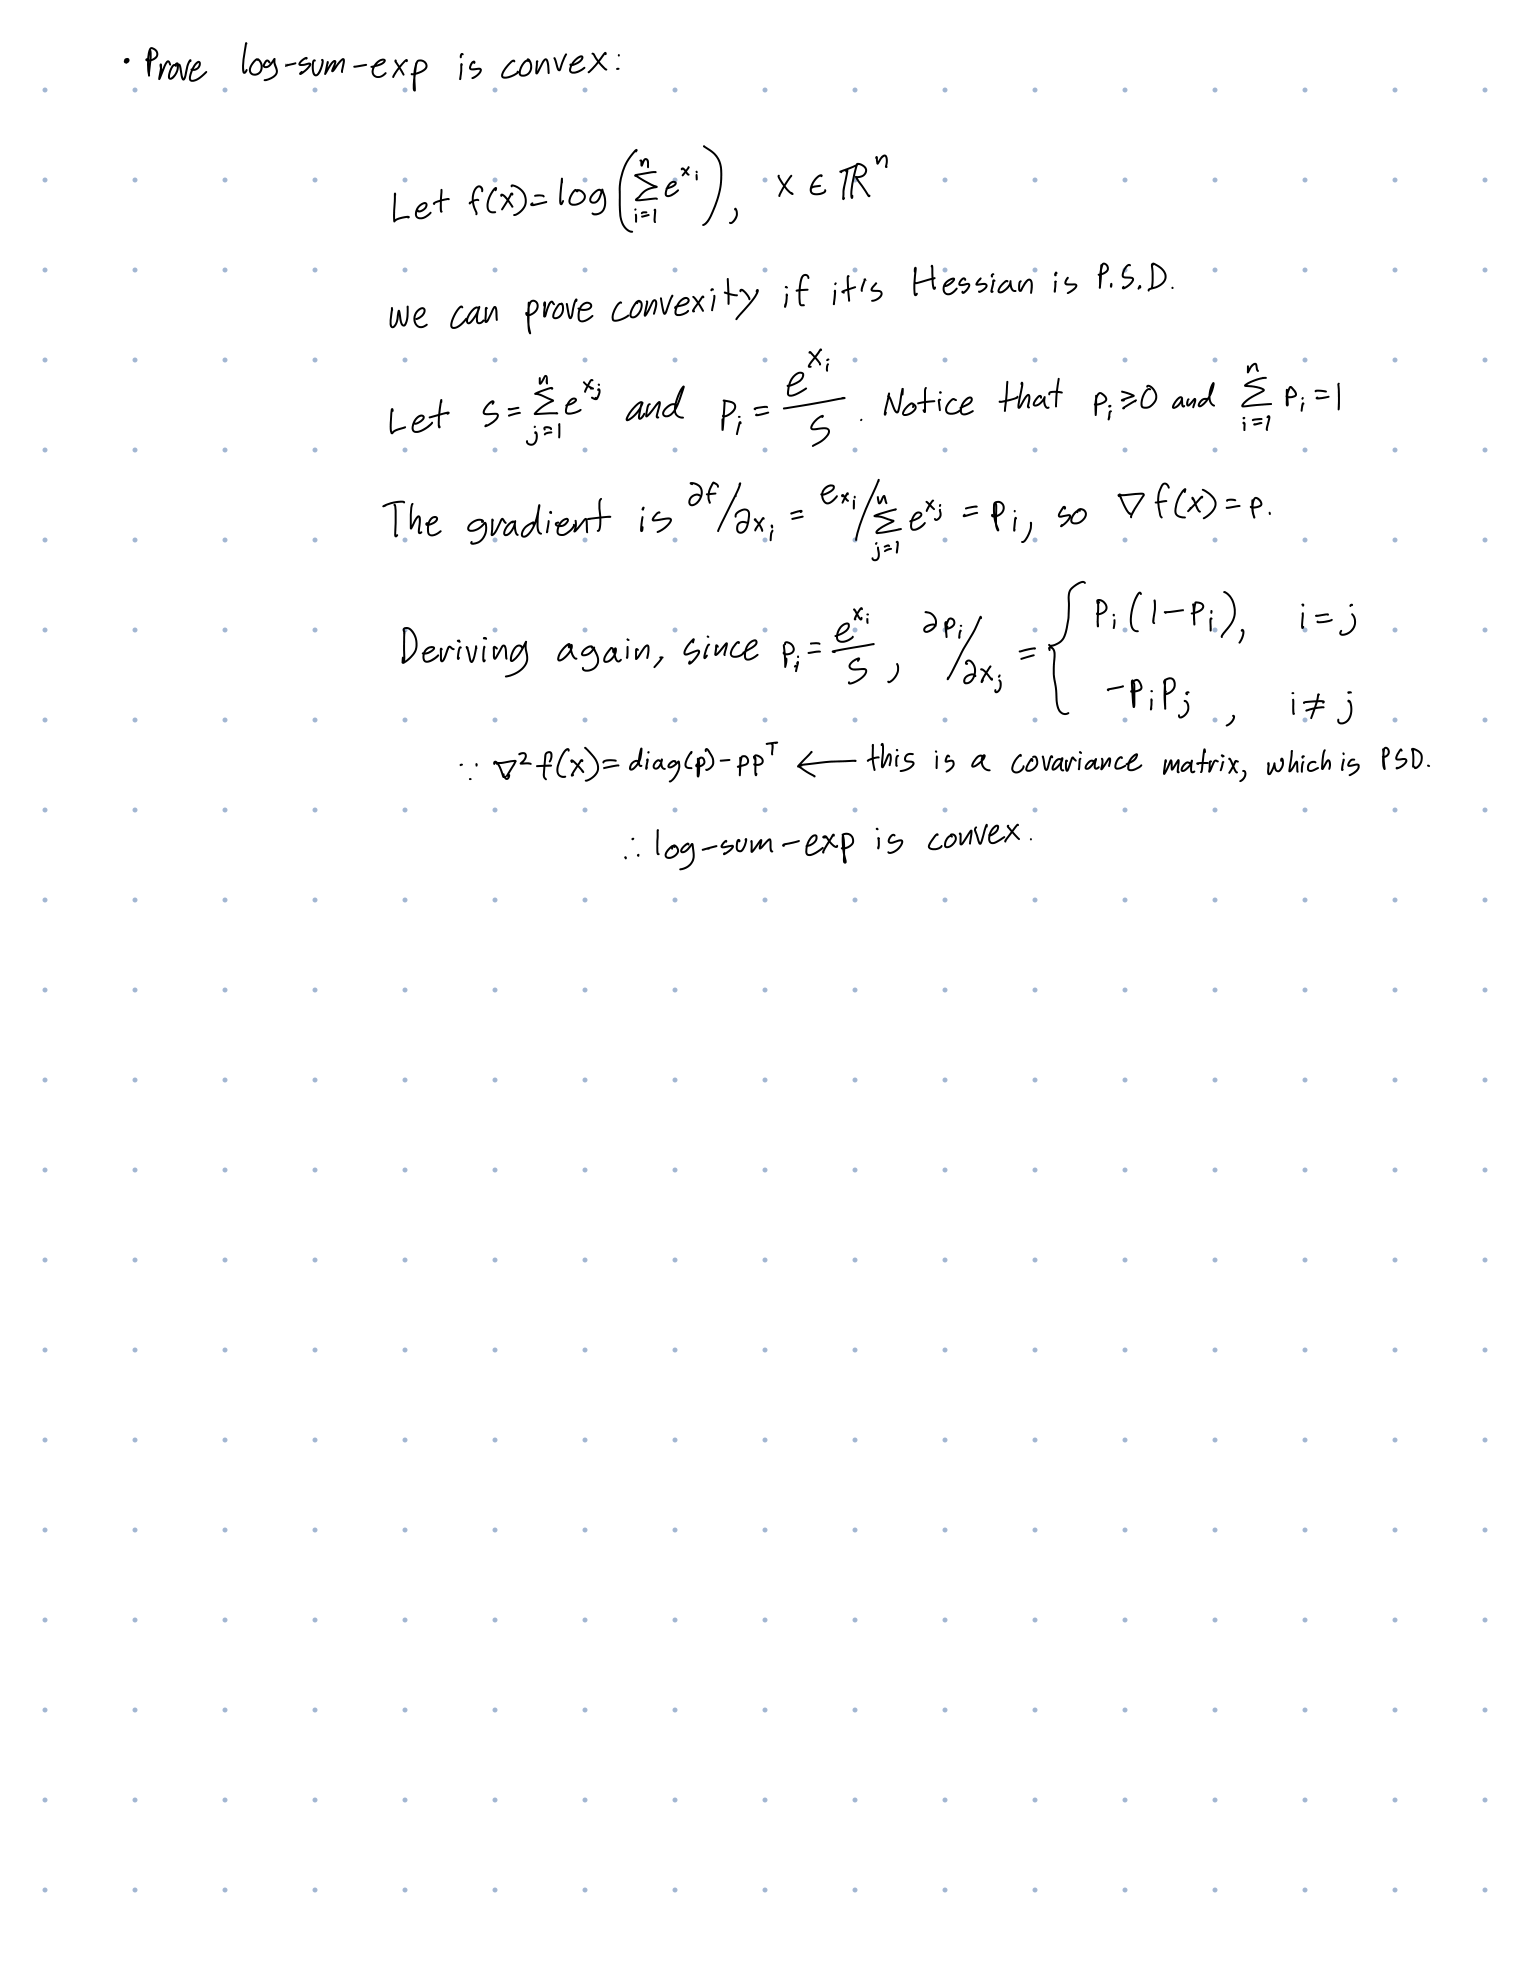

In [8]:
handwriting_path = TEST_DATA / 'samp_solution.pdf'
preview = render_document(handwriting_path, dpi=settings.render_dpi, max_pages=1)[0]
display(Image(data=preview.image_bytes, width=850))

In [9]:
if settings.api_enabled:
    service = RecognitionService(settings)
    handwritten_result = service.recognize_handwriting(handwriting_path, pages=[1])
    page = handwritten_result.pages[0]
    display(Markdown(page.markdown))
    display({
        'equations': [equation.model_dump() for equation in page.equations],
        'uncertainties': page.uncertainties,
        'request_metadata': [item.model_dump() for item in handwritten_result.requests],
    })
else:
    handwritten_result = None
    print('Skipped: add OPENAI_API_KEY to .env, restart the kernel, and rerun.')

- Prove $\log$-sum-exp is convex:
  
  Let $f(x) = \log \left( \sum_{i=1}^n e^{x_i} \right)$, $x \in \mathbb{R}^n$
  
  We can prove convexity if its Hessian is P.S.D.
  
  Let $s = \sum_{j=1}^n e^{x_j}$ and $p_i = \frac{e^{x_i}}{s}$. Notice that $p_i \geq 0$ and $\sum_{i=1}^n p_i = 1$
  
  The gradient is $\frac{\partial f}{\partial x_i} = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}} = p_i$, so $\nabla f(x) = p$.
  
  Deriving again, since $p_i = \frac{e^{x_i}}{s}$, $\frac{\partial p_i}{\partial x_j} = \begin{cases} p_i(1-p_i), & i = j \\ -p_i p_j, & i \neq j \end{cases}$
  
  $\therefore \nabla^2 f(x) = \text{diag}(p) - pp^T \quad \leftarrow \text{this is a covariance matrix, which is P.S.D.}$
  
  $\therefore \log$-sum-exp is convex.


{'equations': [{'latex': '\\log \\left( \\sum_{i=1}^n e^{x_i} \\right)',
   'source_text': 'log ( \\sum_{i=1}^n e^{x_i} )',
   'confidence': 0.99,
   'ambiguous': False,
   'alternatives': []},
  {'latex': 'x \\in \\mathbb{R}^n',
   'source_text': 'x \\in TR^n',
   'confidence': 0.95,
   'ambiguous': True,
   'alternatives': ['x \\in \\mathbb{R}^n']},
  {'latex': 's = \\sum_{j=1}^n e^{x_j}',
   'source_text': 's = \\sum_{j=1}^n e^{x_j}',
   'confidence': 0.99,
   'ambiguous': False,
   'alternatives': []},
  {'latex': 'p_i = \\frac{e^{x_i}}{s}',
   'source_text': 'p_i = \\frac{e^{x_i}}{s}',
   'confidence': 0.99,
   'ambiguous': False,
   'alternatives': []},
  {'latex': 'p_i \\geq 0',
   'source_text': 'p_i \\geq 0',
   'confidence': 0.99,
   'ambiguous': False,
   'alternatives': []},
  {'latex': '\\sum_{i=1}^n p_i = 1',
   'source_text': '\\sum_{i=1}^n p_i = 1',
   'confidence': 0.99,
   'ambiguous': False,
   'alternatives': []},
  {'latex': '\\frac{\\partial f}{\\partial x_i} = \\

### Compare easy, incorrect, and ambiguous samples

The recognizer is instructed to preserve mathematical errors and surface uncertain symbols instead of silently correcting them.

In [10]:
comparison_files = [
    TEST_DATA / 'samp_solution.pdf',
    TEST_DATA / 'samp_wrong_solution.pdf',
    TEST_DATA / 'samp_bad_writing.pdf',
]

if settings.api_enabled:
    comparison = {}
    for path in comparison_files:
        result = service.recognize_handwriting(path, pages=[1])
        comparison[path.name] = result.model_dump()
        display(Markdown(f'### {path.name}\n{result.pages[0].markdown}'))
        print('Uncertainties:', result.pages[0].uncertainties)
else:
    print('Skipped API comparison.')

### samp_solution.pdf
- Prove $\log\text{-sum-exp}$ is convex:

Let $f(x) = \log \left( \sum_{i=1}^n e^{x_i} \right)$, $x \in \mathbb{R}^n$

We can prove convexity if its Hessian is P.S.D.

Let $s = \sum_{j=1}^n e^{x_j}$ and $p_i = \frac{e^{x_i}}{s}$. Notice that $p_i \geq 0$ and $\sum_{i=1}^n p_i = 1$.

The gradient is $\frac{\partial f}{\partial x_i} = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}} = p_i$, so $\nabla f(x) = p$.

Deriving again, since $p_i = \frac{e^{x_i}}{s}, \ \frac{\partial p_i}{\partial x_j} = \begin{cases} p_i (1 - p_i), & i = j \\ -p_i p_j, & i \neq j \end{cases}$

Therefore, $\nabla^2 f(x) = \text{diag}(p) - pp^T \leftarrow \text{this is a covariance matrix, which is PSD.}$

Therefore, $\log\text{-sum-exp}$ is convex.

Uncertainties: []


### samp_wrong_solution.pdf
Prove that \( f(x) = x^4 - 2x^2 \) is convex

\[ f'(x) = 4x^3 - 4x \]

\[ f''(x) = 12x^2 - 4 \] ; \( f''(x) \geq 0 \) but \( f''(0) = -4 \) so contradiction

Uncertainties: []


### samp_bad_writing.pdf
$$
\sum_{i=1}^{n} \frac{x_i}{1 + y_i} = \int_{\alpha}^{\beta} \exp(-y^2) \, dy.
$$

Uncertainties: []
